# 03 - Auto-ARIMA: Selecao Automatica de Ordem - SOLUTION

## 1. Teoria: Criterios de Informacao

A selecao automatica de ordem em modelos ARIMA utiliza **criterios de informacao** para balancear ajuste e complexidade do modelo.

### AIC (Akaike Information Criterion)

$$\text{AIC} = -2 \ln(\hat{L}) + 2k$$

onde $\hat{L}$ e a verossimilhanca maximizada e $k$ e o numero de parametros estimados.

### BIC (Bayesian Information Criterion)

$$\text{BIC} = -2 \ln(\hat{L}) + k \ln(n)$$

onde $n$ e o tamanho da amostra. O BIC penaliza mais fortemente modelos complexos quando $\ln(n) > 2$, ou seja, $n > 7$.

### AICc (AIC corrigido para amostras finitas)

$$\text{AICc} = \text{AIC} + \frac{2k(k+1)}{n - k - 1}$$

O AICc adiciona uma correcao de vies que e relevante quando $n/k$ e pequeno. Para $n \to \infty$, $\text{AICc} \to \text{AIC}$.

### Comparacao

| Criterio | Penalidade | Propriedade | Quando usar |
|----------|-----------|-------------|-------------|
| AIC | $2k$ | Eficiente (minimiza erro de previsao) | Foco em previsao |
| BIC | $k\ln(n)$ | Consistente (seleciona modelo verdadeiro) | Foco em identificacao |
| AICc | $2k + 2k(k+1)/(n-k-1)$ | Corrigido para amostras finitas | Amostras pequenas ($n/k < 40$) |

O **auto_arima** percorre sistematicamente combinacoes de $(p, d, q)$ e $(P, D, Q, m)$, ajustando cada modelo e selecionando aquele com menor criterio de informacao.

## 2. Setup e Dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import time

from chronobox import ARIMA, auto_arima
from chronobox.tests_stat import ljung_box_test
from chronobox.visualization import plot_diagnostics, plot_forecast, set_theme
from chronobox.visualization.diagnostics_plot import _compute_acf, _compute_pacf

set_theme('professional')
np.random.seed(42)

DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), 'data')
OUTPUT_DIR = os.path.join(os.path.dirname(os.getcwd()), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('chronobox importado com sucesso!')

chronobox importado com sucesso!


Airline (log): 144 observacoes
Nile: 100 observacoes


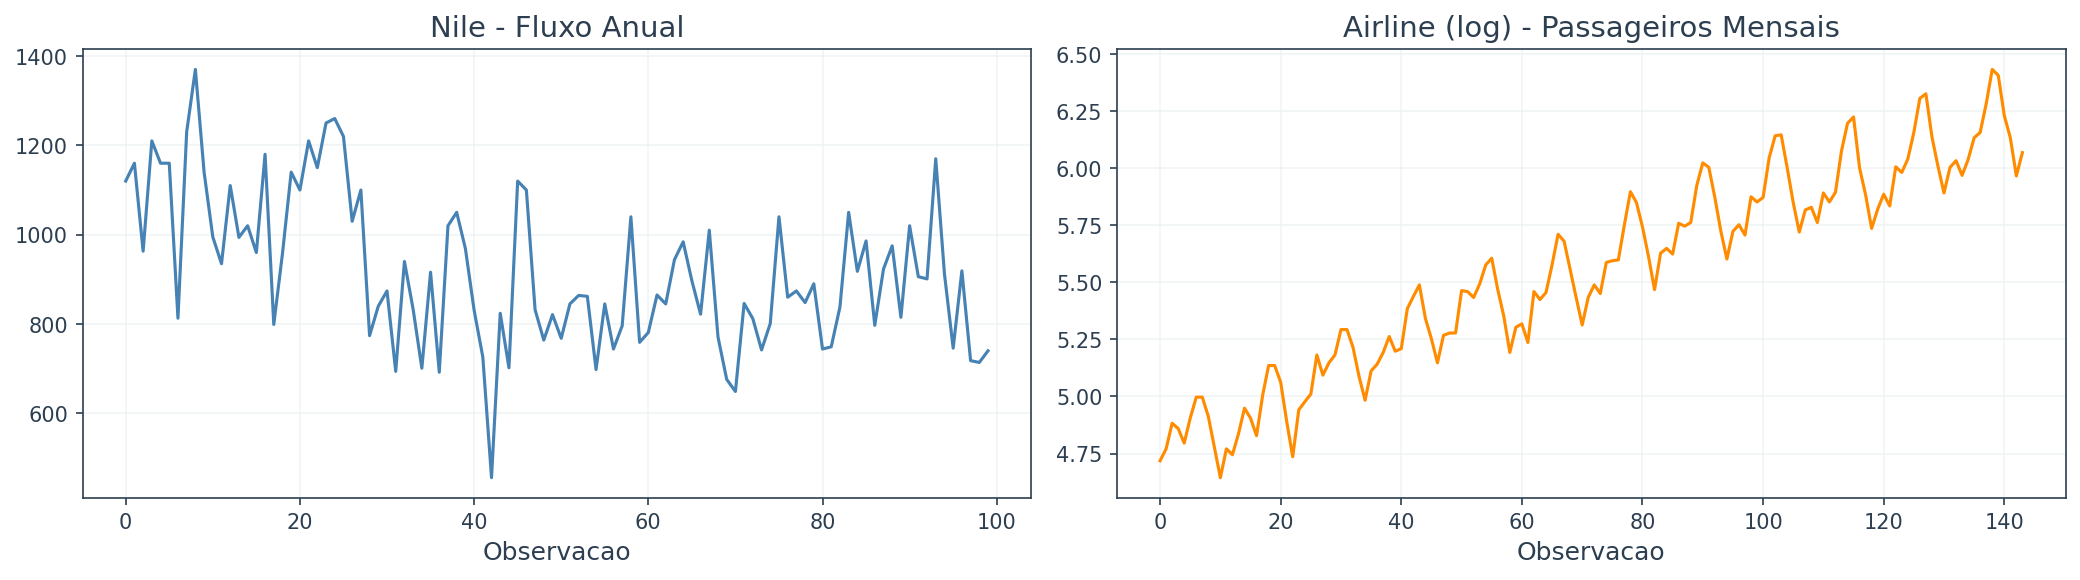

In [2]:
# Carregar dados Airline (log-transformado)
airline = pd.read_csv(os.path.join(DATA_DIR, 'airline.csv'), parse_dates=['date'])
airline.set_index('date', inplace=True)
y_airline = np.log(airline['passengers'].values)
print(f'Airline (log): {len(y_airline)} observacoes')

# Carregar dados Nile
nile = pd.read_csv(os.path.join(DATA_DIR, 'nile.csv'), parse_dates=['date'])
nile.set_index('date', inplace=True)
y_nile = nile['flow'].values
print(f'Nile: {len(y_nile)} observacoes')

# Visualizacao rapida
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(y_nile, color='steelblue')
axes[0].set_title('Nile - Fluxo Anual')
axes[0].set_xlabel('Observacao')
axes[1].plot(y_airline, color='darkorange')
axes[1].set_title('Airline (log) - Passageiros Mensais')
axes[1].set_xlabel('Observacao')
plt.tight_layout()
plt.show()

## 3. Auto-ARIMA: Serie Nao-Sazonal (Nile)

In [3]:
# Auto-ARIMA stepwise no Nile
print('=== Auto-ARIMA Stepwise no Nile ===')
best_nile = auto_arima(
    y_nile,
    seasonal=False,
    max_p=5, max_q=5,
    information_criterion='aicc',
    stepwise=True,
    trace=True
)
print(f'\nModelo selecionado: {best_nile.model_name}')
print(best_nile.summary())

=== Auto-ARIMA Stepwise no Nile ===
  Determined d = 0
Stepwise model selection:
  ARIMA(0,0,0)                        : AICC=1313.1552
  ARIMA(2,0,2)                        : AICC=1285.3862
  ARIMA(1,0,0)                        : AICC=1286.1559


/home/guhaase/.local/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


  ARIMA(0,0,1)                        : AICC=1295.6917
  ARIMA(1,0,2)                        : AICC=1283.9462
  ARIMA(3,0,2)                        : AICC=1287.5806
  ARIMA(2,0,1)                        : AICC=1283.4628
  ARIMA(2,0,3)                        : AICC=1288.5618
  ARIMA(1,0,1)                        : AICC=1282.5475
  ARIMA(1,0,3)                        : AICC=1285.7162
  ARIMA(3,0,1)                        : AICC=1285.3776


  ARIMA(3,0,3)                        : AICC=1290.8103
  ARIMA(0,0,2)                        : AICC=1291.8956
  ARIMA(2,0,0)                        : AICC=1284.4146

  Best model: ARIMA(1,0,1)  AICC=1282.5475

Modelo selecionado: ARIMA(1,0,1)
                         Model: ARIMA(1,0,1)                          
  Nobs: 100    Effective Nobs: 100
  Log-Likelihood: -637.0632
  AIC: 1282.1265    BIC: 1292.5471    AICc: 1282.5475    HQIC: 1286.3439
----------------------------------------------------------------------
  Parameter         Estimate    Std.Err    t-value    p-value
----------------------------------------------------------------------
  const             919.3487    59.2591    15.5141     0.0000
  ar.L1               0.8369     0.1190     7.0319     0.0000
  ma.L1              -0.4779     0.1996    -2.3945     0.0186
  sigma2          19945.3009    72.5664   274.8560     0.0000
  Residual std: 142.6413    Mean: -2.2675
  Ljung-Box(lag=10): stat=9.6504  p-value=0.4717


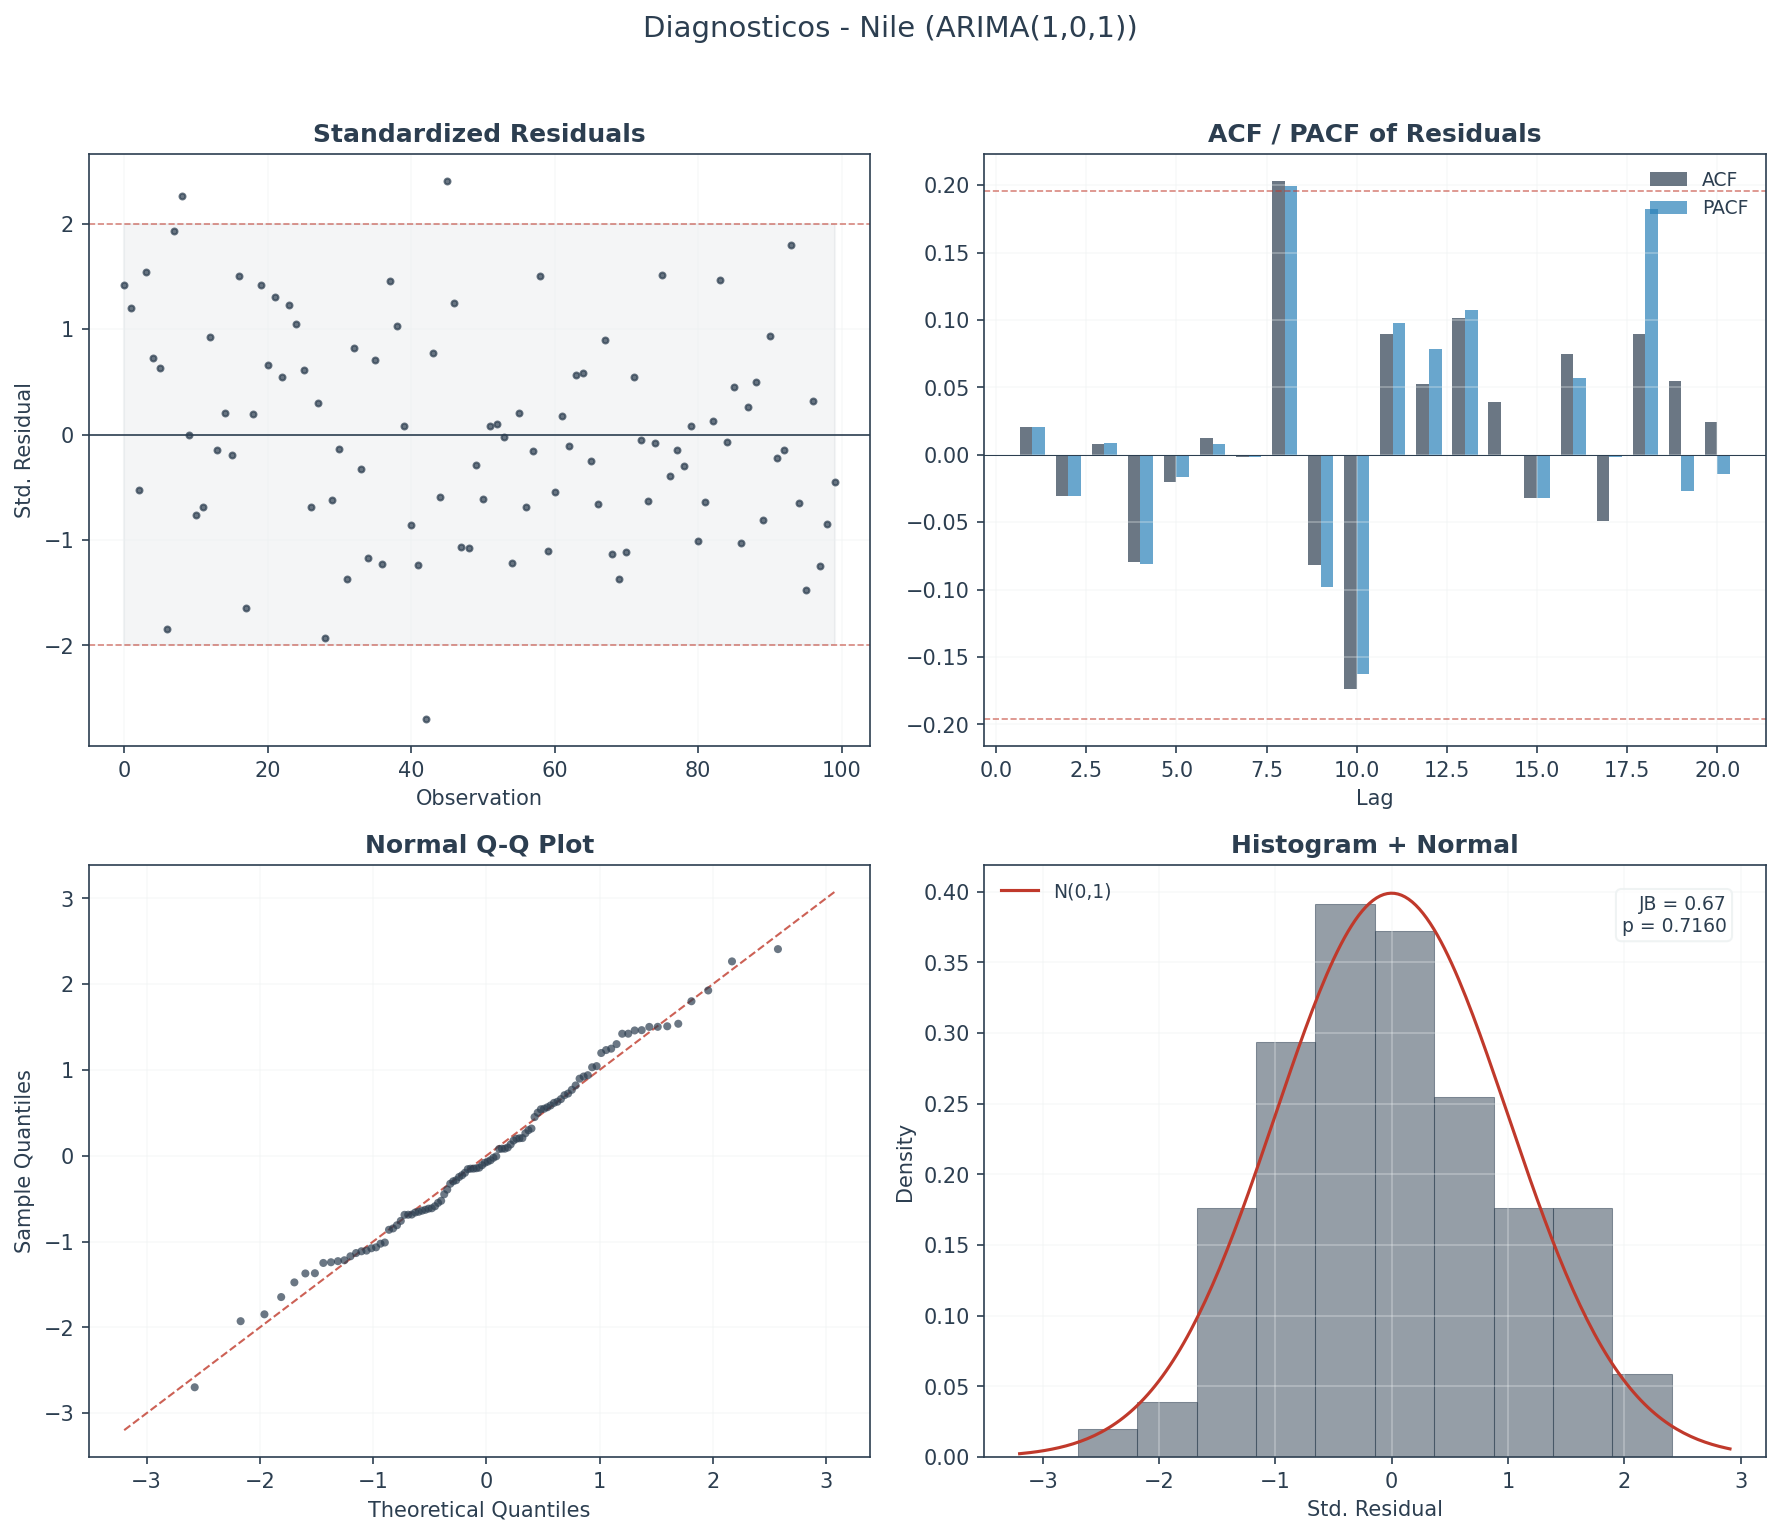

Ljung-Box (lag=10): estatistica=9.65, p-valor=0.4717
Residuos nao apresentam autocorrelacao significativa (bom ajuste).


In [4]:
# Diagnosticos do modelo selecionado para o Nile
fig = plot_diagnostics(best_nile)
plt.suptitle(f'Diagnosticos - Nile ({best_nile.model_name})', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Teste de Ljung-Box nos residuos
lb_result = ljung_box_test(best_nile.residuals, lags=10)
print(f'Ljung-Box (lag=10): estatistica={lb_result.statistic:.2f}, p-valor={lb_result.pvalue:.4f}')
if lb_result.pvalue > 0.05:
    print('Residuos nao apresentam autocorrelacao significativa (bom ajuste).')
else:
    print('Residuos com autocorrelacao significativa (ajuste pode ser melhorado).')

## 4. Auto-ARIMA: Serie Sazonal (Airline)

In [5]:
# Auto-ARIMA com sazonalidade na serie Airline
print('=== Auto-ARIMA Sazonal na Airline (m=12) ===')
best_airline = auto_arima(
    y_airline,
    seasonal=True, m=12,
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    information_criterion='aicc',
    stepwise=True,
    trace=True
)
print(f'\nModelo selecionado: {best_airline.model_name}')
print(best_airline.summary())

=== Auto-ARIMA Sazonal na Airline (m=12) ===
  Determined d = 2
  Determined D = 1
Stepwise model selection:
  ARIMA(0,2,0)(0,1,0)[12]             : AICC=-302.4951


/home/guhaase/.local/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


  ARIMA(2,2,2)(1,1,1)[12]             : AICC=-463.0866
  ARIMA(1,2,0)(1,1,0)[12]             : AICC=-394.3812


  ARIMA(0,2,1)(0,1,1)[12]             : AICC=-454.3653


/home/guhaase/projetos/chronobox/chronobox/models/arima.py:333: RuntimeWarning: overflow encountered in square
  css_resid**2


...

  ARIMA(2,2,0)(0,1,1)[12]             : AICC=-420.3443


  ARIMA(0,2,3)(0,1,1)[12]             : AICC=-467.0582


  ARIMA(0,2,2)(0,1,0)[12]             : AICC=-437.5129


  ARIMA(0,2,2)(0,1,2)[12]             : AICC=-467.5138


  ARIMA(1,2,3)(0,1,1)[12]             : AICC=-464.8016

  Best model: ARIMA(0,2,2)(0,1,1)[12]  AICC=-469.1069

Modelo selecionado: ARIMA(0,2,2)(0,1,1)[12]
                    Model: ARIMA(0,2,2)(0,1,1)[12]                    
  Nobs: 144    Effective Nobs: 130
  Log-Likelihood: 238.7134
  AIC: -469.4269    BIC: -457.9567    AICc: -469.1069    HQIC: -464.7662
----------------------------------------------------------------------
  Parameter         Estimate    Std.Err    t-value    p-value
----------------------------------------------------------------------
  ma.L1              -1.3901     0.0949   -14.6463     0.0000
  ma.L2               0.3901     0.0907     4.2983     0.0000
  ma.S.L12           -0.5495     0.0745    -7.3728     0.0000
  sigma2              0.0014     0.0002     7.7962     0.0000
  Residual std: 0.0475    Mean: -0.1249
  Ljung-Box(lag=10): stat=122.4431  p-value=0.0000


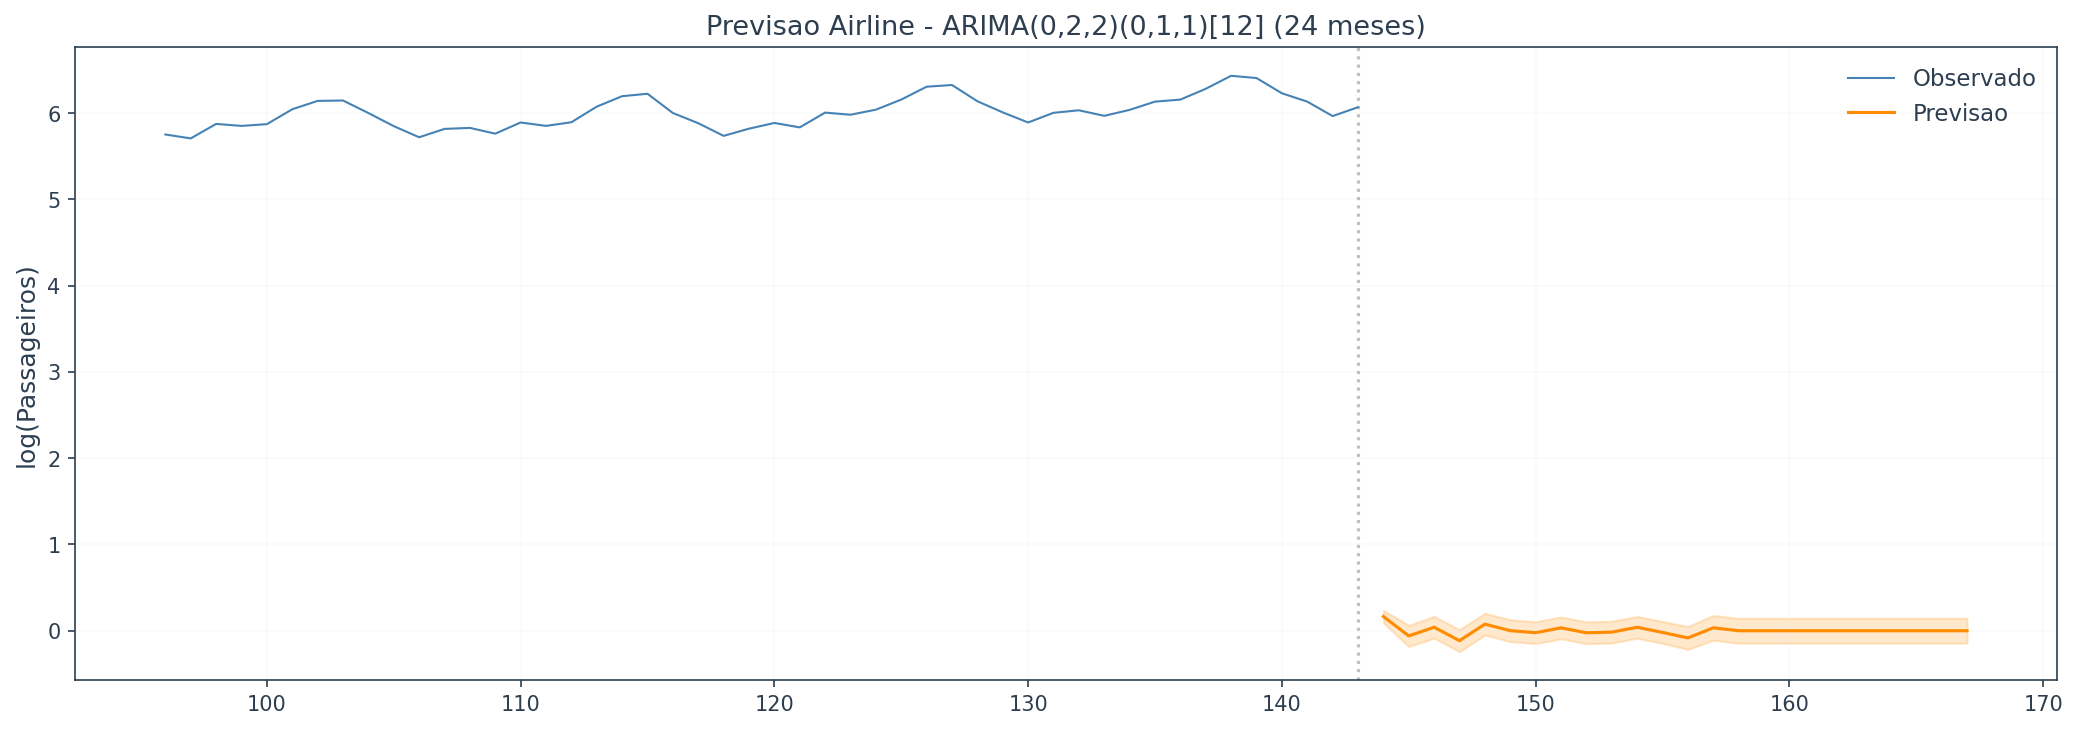

Previsao para os proximos 24 meses (escala log):
  Media: 0.0020
  Min:   -0.1152
  Max:   0.1645


In [6]:
# Previsao de 24 passos a frente com o melhor modelo Airline
fc_airline = best_airline.forecast(steps=24)

fig, ax = plt.subplots(figsize=(14, 5))
n_show = 48
ax.plot(range(len(y_airline)-n_show, len(y_airline)), y_airline[-n_show:], 
        color='steelblue', linewidth=1.0, label='Observado')
x_fc = np.arange(len(y_airline), len(y_airline) + 24)
ax.plot(x_fc, fc_airline['forecast'], color='darkorange', linewidth=1.5, label='Previsao')
ax.fill_between(x_fc, fc_airline['lower'], fc_airline['upper'], alpha=0.2, color='darkorange')
ax.axvline(len(y_airline)-1, color='gray', linestyle=':', alpha=0.5)
ax.set_title(f'Previsao Airline - {best_airline.model_name} (24 meses)', fontsize=13)
ax.set_ylabel('log(Passageiros)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fc_vals = fc_airline['forecast']
print(f'Previsao para os proximos 24 meses (escala log):')
print(f'  Media: {fc_vals.mean():.4f}')
print(f'  Min:   {fc_vals.min():.4f}')
print(f'  Max:   {fc_vals.max():.4f}')

## 5. Comparacao de Criterios de Informacao

In [7]:
# Grid de modelos SARIMA ajustados manualmente
modelos_airline = [
    ((0,1,1), (0,1,1,12)),
    ((1,1,0), (0,1,1,12)),
    ((1,1,1), (0,1,1,12)),
    ((0,1,1), (1,1,1,12)),
    ((1,1,1), (1,1,1,12)),
    ((2,1,1), (0,1,1,12)),
    ((0,1,2), (0,1,1,12)),
]

resultados = []
for order, seasonal in modelos_airline:
    try:
        m = ARIMA(order=order, seasonal_order=seasonal)
        r = m.fit(y_airline)
        resultados.append({
            'Modelo': m.model_name,
            'order': order,
            'seasonal': seasonal,
            'AIC': r.aic,
            'BIC': r.bic,
            'AICc': r.aicc,
            'LogLik': r.loglike,
            'Params': len(r.params),
            'result': r
        })
    except Exception as e:
        print(f'Falha: {e}')

df_comp = pd.DataFrame(resultados)
df_comp_display = df_comp[['Modelo', 'AIC', 'BIC', 'AICc', 'LogLik', 'Params']].sort_values('AICc')
print(df_comp_display.to_string(index=False))
print(f'\nMelhor por AICc: {df_comp_display.iloc[0]["Modelo"]}')
print(f'Melhor por BIC: {df_comp.sort_values("BIC").iloc[0]["Modelo"]}')

                 Modelo         AIC         BIC        AICc     LogLik  Params
ARIMA(0,1,1)(0,1,1)[12] -483.392974 -474.767382 -483.203997 244.696487       3
ARIMA(0,1,1)(1,1,1)[12] -481.906294 -470.405504 -481.588833 244.953147       4
ARIMA(1,1,1)(0,1,1)[12] -481.892990 -470.392201 -481.575530 244.946495       4
ARIMA(1,1,0)(0,1,1)[12] -481.483828 -472.858236 -481.294852 243.741914       3
ARIMA(0,1,2)(0,1,1)[12] -481.610317 -470.109528 -481.292857 244.805158       4
ARIMA(1,1,1)(1,1,1)[12] -480.303782 -465.927795 -479.823782 245.151891       5
ARIMA(2,1,1)(0,1,1)[12] -479.812547 -465.436561 -479.332547 244.906274       5

Melhor por AICc: ARIMA(0,1,1)(0,1,1)[12]
Melhor por BIC: ARIMA(0,1,1)(0,1,1)[12]


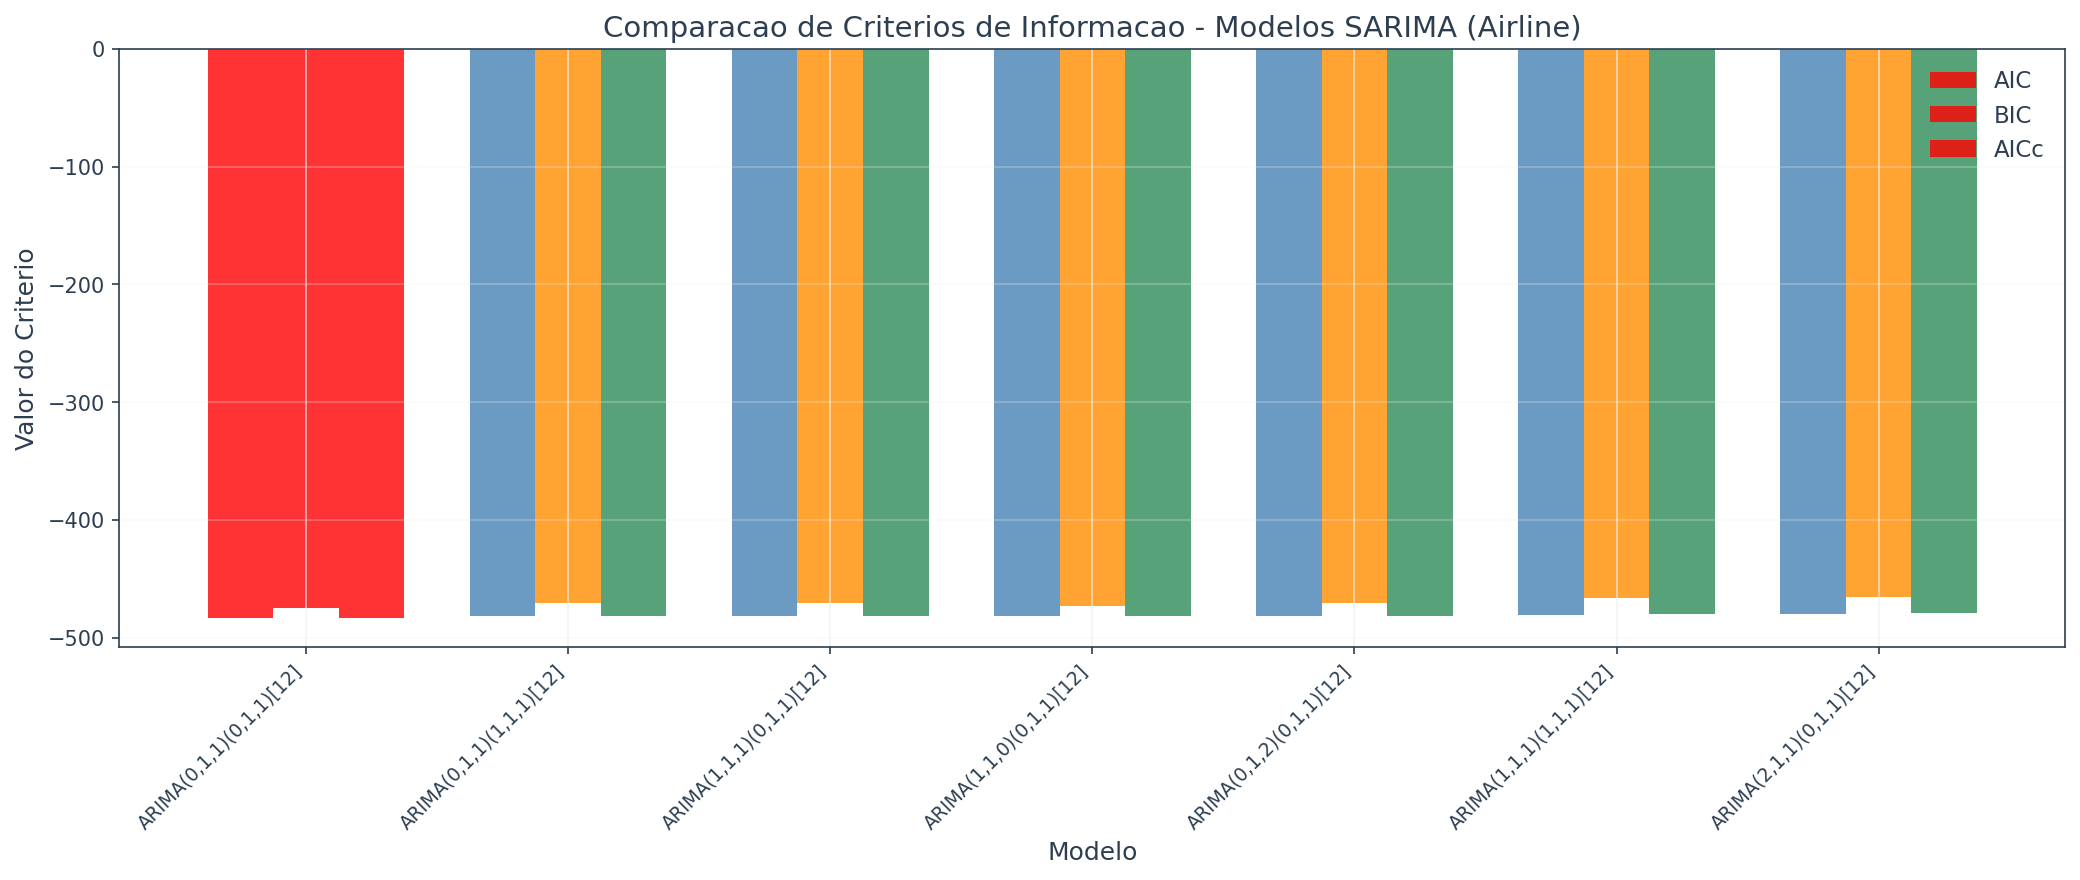

Barras vermelhas indicam o melhor modelo para cada criterio.


In [8]:
# Grafico de barras comparando AIC/BIC/AICc
df_plot = df_comp_display.copy()
modelos_nomes = df_plot['Modelo'].values
x = np.arange(len(modelos_nomes))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

aic_vals = df_plot['AIC'].values
bic_vals = df_plot['BIC'].values
aicc_vals = df_plot['AICc'].values

# Cores: melhor em vermelho, demais em azul
colors_aic = ['red' if v == aic_vals.min() else 'steelblue' for v in aic_vals]
colors_bic = ['red' if v == bic_vals.min() else 'darkorange' for v in bic_vals]
colors_aicc = ['red' if v == aicc_vals.min() else 'seagreen' for v in aicc_vals]

bars1 = ax.bar(x - width, aic_vals, width, label='AIC', color=colors_aic, alpha=0.8)
bars2 = ax.bar(x, bic_vals, width, label='BIC', color=colors_bic, alpha=0.8)
bars3 = ax.bar(x + width, aicc_vals, width, label='AICc', color=colors_aicc, alpha=0.8)

ax.set_xlabel('Modelo')
ax.set_ylabel('Valor do Criterio')
ax.set_title('Comparacao de Criterios de Informacao - Modelos SARIMA (Airline)')
ax.set_xticks(x)
ax.set_xticklabels(modelos_nomes, rotation=45, ha='right', fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Barras vermelhas indicam o melhor modelo para cada criterio.')

## 6. Validacao Cruzada Temporal (Rolling Window)

In [9]:
def rolling_cv(y, order, seasonal_order=None, n_folds=5, horizon=12, min_train=60):
    """
    Validacao cruzada temporal com janela expansiva.
    """
    n = len(y)
    fold_size = (n - min_train - horizon) // n_folds
    results = []
    
    for i in range(n_folds):
        train_end = min_train + i * fold_size
        test_end = min(train_end + horizon, n)
        
        y_train = y[:train_end]
        y_test = y[train_end:test_end]
        
        if len(y_test) == 0:
            break
        
        try:
            if seasonal_order is not None:
                model = ARIMA(order=order, seasonal_order=seasonal_order)
            else:
                model = ARIMA(order=order)
            res = model.fit(y_train)
            fc = res.forecast(steps=len(y_test))
            forecast_vals = fc['forecast']
            
            rmse = np.sqrt(np.mean((y_test - forecast_vals) ** 2))
            mae = np.mean(np.abs(y_test - forecast_vals))
            
            results.append({
                'fold': i + 1,
                'train_size': len(y_train),
                'test_size': len(y_test),
                'rmse': rmse,
                'mae': mae
            })
        except Exception as e:
            print(f'Fold {i+1} falhou: {e}')
    
    return pd.DataFrame(results)

print('Funcao rolling_cv definida.')

Funcao rolling_cv definida.


In [10]:
# Validacao cruzada para 4 modelos na serie Airline
modelos_cv = {
    'ARIMA(1,1,1)': {'order': (1,1,1), 'seasonal_order': None},
    'SARIMA(0,1,1)(0,1,1,12)': {'order': (0,1,1), 'seasonal_order': (0,1,1,12)},
    'SARIMA(1,1,1)(0,1,1,12)': {'order': (1,1,1), 'seasonal_order': (0,1,1,12)},
    'SARIMA(0,1,1)(1,1,1,12)': {'order': (0,1,1), 'seasonal_order': (1,1,1,12)},
}

cv_results = {}
for nome, params in modelos_cv.items():
    print(f'Avaliando {nome}...')
    cv_df = rolling_cv(y_airline, **params, n_folds=5, horizon=12, min_train=84)
    cv_results[nome] = cv_df
    print(f'  RMSE medio: {cv_df["rmse"].mean():.4f}, MAE medio: {cv_df["mae"].mean():.4f}')

print('\n=== Resumo da Validacao Cruzada ===')
print(f'{"Modelo":<35} {"RMSE medio":>12} {"MAE medio":>12}')
print('-' * 60)
for nome, cv_df in cv_results.items():
    print(f'{nome:<35} {cv_df["rmse"].mean():>12.4f} {cv_df["mae"].mean():>12.4f}')

melhor_cv = min(cv_results.items(), key=lambda x: x[1]['rmse'].mean())
print(f'\nMelhor modelo por CV-RMSE: {melhor_cv[0]}')

Avaliando ARIMA(1,1,1)...


  RMSE medio: 5.9145, MAE medio: 5.9126

/home/guhaase/.local/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]



Avaliando SARIMA(0,1,1)(0,1,1,12)...


  RMSE medio: 5.9141, MAE medio: 5.9122
Avaliando SARIMA(1,1,1)(0,1,1,12)...


/home/guhaase/.local/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


  RMSE medio: 5.9139, MAE medio: 5.9119
Avaliando SARIMA(0,1,1)(1,1,1,12)...


  RMSE medio: 5.9140, MAE medio: 5.9120

=== Resumo da Validacao Cruzada ===
Modelo                                RMSE medio    MAE medio
------------------------------------------------------------
ARIMA(1,1,1)                              5.9145       5.9126
SARIMA(0,1,1)(0,1,1,12)                   5.9141       5.9122
SARIMA(1,1,1)(0,1,1,12)                   5.9139       5.9119
SARIMA(0,1,1)(1,1,1,12)                   5.9140       5.9120

Melhor modelo por CV-RMSE: SARIMA(1,1,1)(0,1,1,12)


/tmp/ipykernel_194713/3198292819.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nomes, rotation=30, ha='right', fontsize=9)


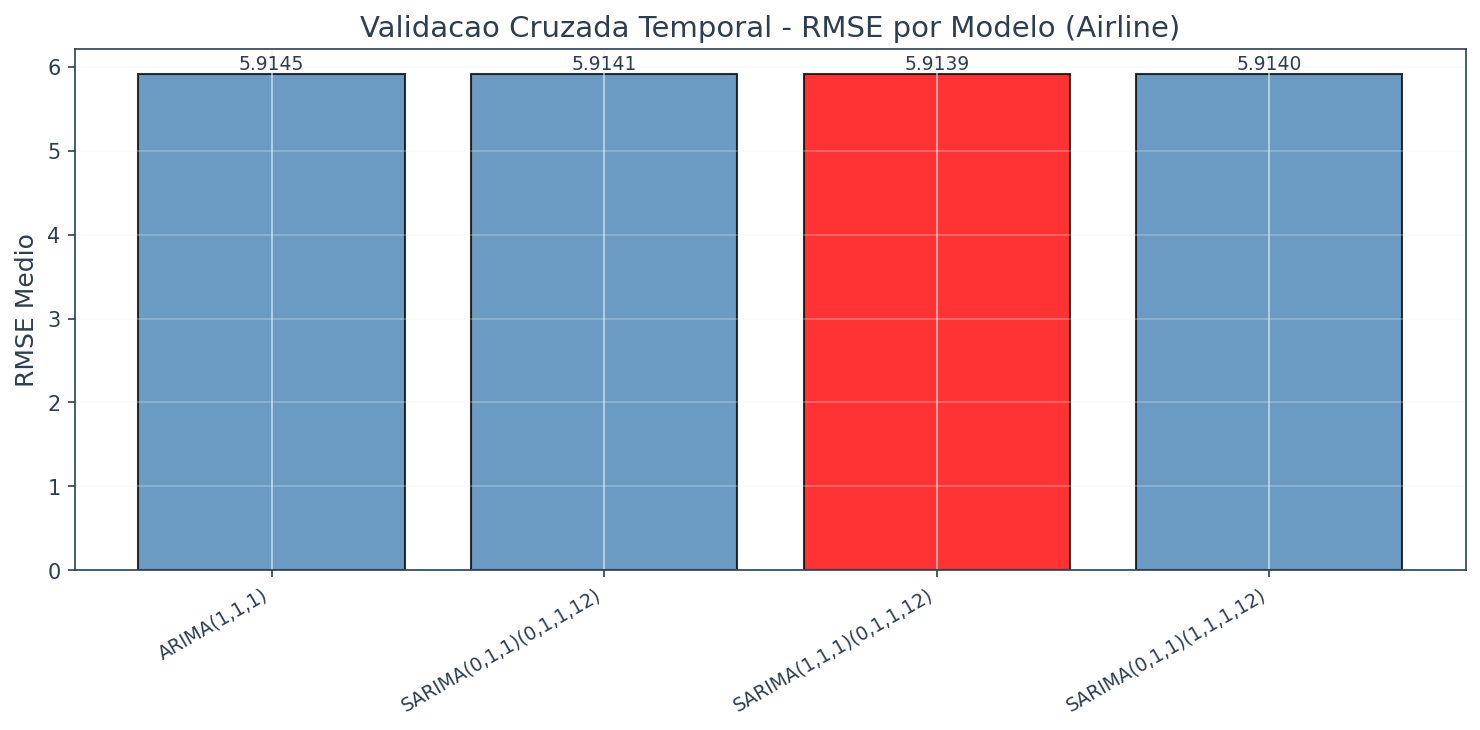

In [11]:
# Grafico de barras do RMSE medio por modelo
nomes = list(cv_results.keys())
rmse_medios = [cv_results[n]['rmse'].mean() for n in nomes]

colors = ['red' if r == min(rmse_medios) else 'steelblue' for r in rmse_medios]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(nomes, rmse_medios, color=colors, alpha=0.8, edgecolor='black')
ax.set_ylabel('RMSE Medio')
ax.set_title('Validacao Cruzada Temporal - RMSE por Modelo (Airline)')
ax.set_xticklabels(nomes, rotation=30, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, rmse_medios):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

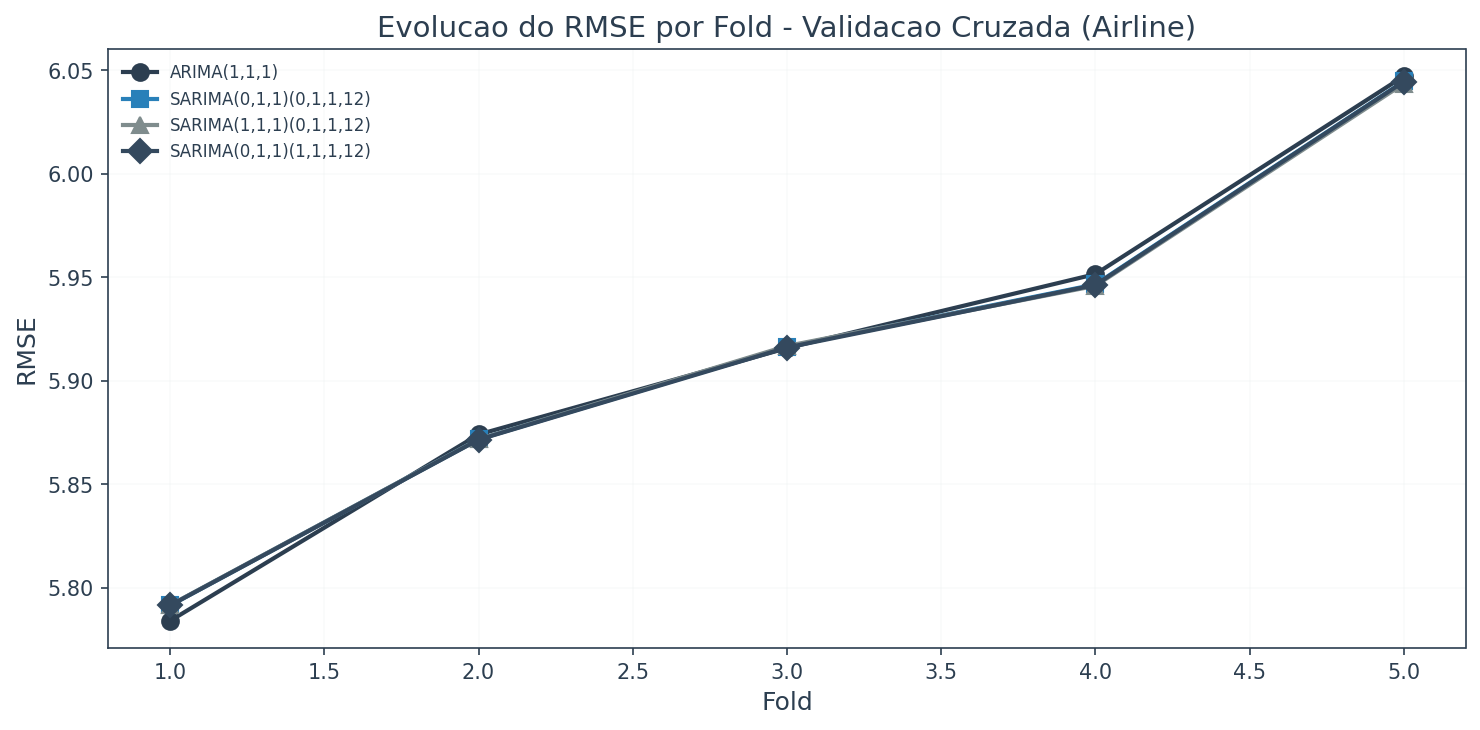

Nota: aumento do RMSE nos folds finais pode indicar mudanca estrutural na serie.


In [12]:
# Evolucao do RMSE por fold
fig, ax = plt.subplots(figsize=(10, 5))

markers = ['o', 's', '^', 'D']
for (nome, cv_df), marker in zip(cv_results.items(), markers):
    ax.plot(cv_df['fold'], cv_df['rmse'], marker=marker, label=nome, linewidth=2, markersize=8)

ax.set_xlabel('Fold')
ax.set_ylabel('RMSE')
ax.set_title('Evolucao do RMSE por Fold - Validacao Cruzada (Airline)')
ax.legend(loc='best', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Nota: aumento do RMSE nos folds finais pode indicar mudanca estrutural na serie.')

## 7. Stepwise vs Grid Search

In [13]:
# Comparacao de tempo: Stepwise vs Grid Search
print('=== Comparacao de Tempo: Stepwise vs Grid Search ===')
print('(Serie Nile, nao sazonal)\n')

# Stepwise
t0 = time.time()
res_stepwise = auto_arima(
    y_nile, seasonal=False,
    max_p=5, max_q=5,
    information_criterion='aicc',
    stepwise=True, trace=False
)
t_stepwise = time.time() - t0

# Grid Search
t0 = time.time()
res_grid = auto_arima(
    y_nile, seasonal=False,
    max_p=5, max_q=5,
    information_criterion='aicc',
    stepwise=False, trace=False
)
t_grid = time.time() - t0

print(f'{"Metodo":<20} {"Modelo":<20} {"AICc":>10} {"Tempo (s)":>12}')
print('-' * 65)
print(f'{"Stepwise":<20} {res_stepwise.model_name:<20} {res_stepwise.aicc:>10.2f} {t_stepwise:>12.3f}')
print(f'{"Grid Search":<20} {res_grid.model_name:<20} {res_grid.aicc:>10.2f} {t_grid:>12.3f}')

speedup = t_grid / t_stepwise if t_stepwise > 0 else float('inf')
print(f'\nSpeedup do Stepwise: {speedup:.1f}x mais rapido')

if res_stepwise.model_name == res_grid.model_name:
    print('Ambos metodos selecionaram o mesmo modelo!')
else:
    print(f'Modelos diferentes: Stepwise={res_stepwise.model_name}, Grid={res_grid.model_name}')
    print(f'Diferenca no AICc: {abs(res_stepwise.aicc - res_grid.aicc):.4f}')

=== Comparacao de Tempo: Stepwise vs Grid Search ===
(Serie Nile, nao sazonal)



/home/guhaase/.local/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


/home/guhaase/.local/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


/home/guhaase/projetos/chronobox/chronobox/models/arima.py:333: RuntimeWarning: overflow encountered in square
  css_resid**2


Metodo               Modelo                     AICc    Tempo (s)
-----------------------------------------------------------------
Stepwise             ARIMA(1,0,1)            1282.55        3.086
Grid Search          ARIMA(1,0,1)            1282.55       14.700

Speedup do Stepwise: 4.8x mais rapido
Ambos metodos selecionaram o mesmo modelo!


## Exercicio 1: Auto vs Manual no brazil_ipca.csv - SOLUCAO

In [14]:
# Exercicio 1 - SOLUCAO COMPLETA
ipca = pd.read_csv(os.path.join(DATA_DIR, 'brazil_ipca.csv'), parse_dates=['date'])
ipca.set_index('date', inplace=True)
y_ipca = ipca['ipca'].values

print('=== Auto-ARIMA no IPCA ===')
best_auto = auto_arima(
    y_ipca, seasonal=True, m=12,
    max_p=3, max_q=3, max_P=2, max_Q=2,
    information_criterion='aicc',
    stepwise=True, trace=True
)
print()
print(best_auto.summary())

=== Auto-ARIMA no IPCA ===
  Determined d = 0
  Determined D = 0
Stepwise model selection:
  ARIMA(0,0,0)(0,0,0)[12]             : AICC=-93.7260


/home/guhaase/.local/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


  ARIMA(2,0,2)(1,0,1)[12]             : AICC=-260.3990


  ARIMA(1,0,0)(1,0,0)[12]             : AICC=-247.2121


  ARIMA(0,0,1)(0,0,1)[12]             : AICC=-211.6040


...

  ARIMA(1,0,2)(2,0,1)[12]             : AICC=-262.5601


  ARIMA(1,0,2)(1,0,0)[12]             : AICC=-260.1119


  ARIMA(1,0,2)(1,0,2)[12]             : AICC=-260.7038


  ARIMA(0,0,1)(1,0,1)[12]             : AICC=-212.5872


  ARIMA(0,0,3)(1,0,1)[12]             : AICC=-261.9933

  Best model: ARIMA(1,0,2)(1,0,1)[12]  AICC=-262.8522

                    Model: ARIMA(1,0,2)(1,0,1)[12]                    
  Nobs: 240    Effective Nobs: 240
  Log-Likelihood: 138.6675
  AIC: -263.3349    BIC: -238.9705    AICc: -262.8522    HQIC: -253.5178
----------------------------------------------------------------------
  Parameter         Estimate    Std.Err    t-value    p-value
----------------------------------------------------------------------
  const               0.3471     0.0328    10.5685     0.0000
  ar.L1               0.3460     0.1283     2.6970     0.0075
  ma.L1               0.4876     0.1295     3.7642     0.0002
  ma.L2               0.3154     0.0956     3.2984     0.0011
  ar.S.L12            1.0889     0.0172    63.2489     0.0000
  ma.S.L12           -1.0533     0.0385   -27.3349     0.0000
  sigma2              0.0176     0.0015    11.6236     0.0000
  Residual std: 0.1349    Mean: -0.0015
  Lju

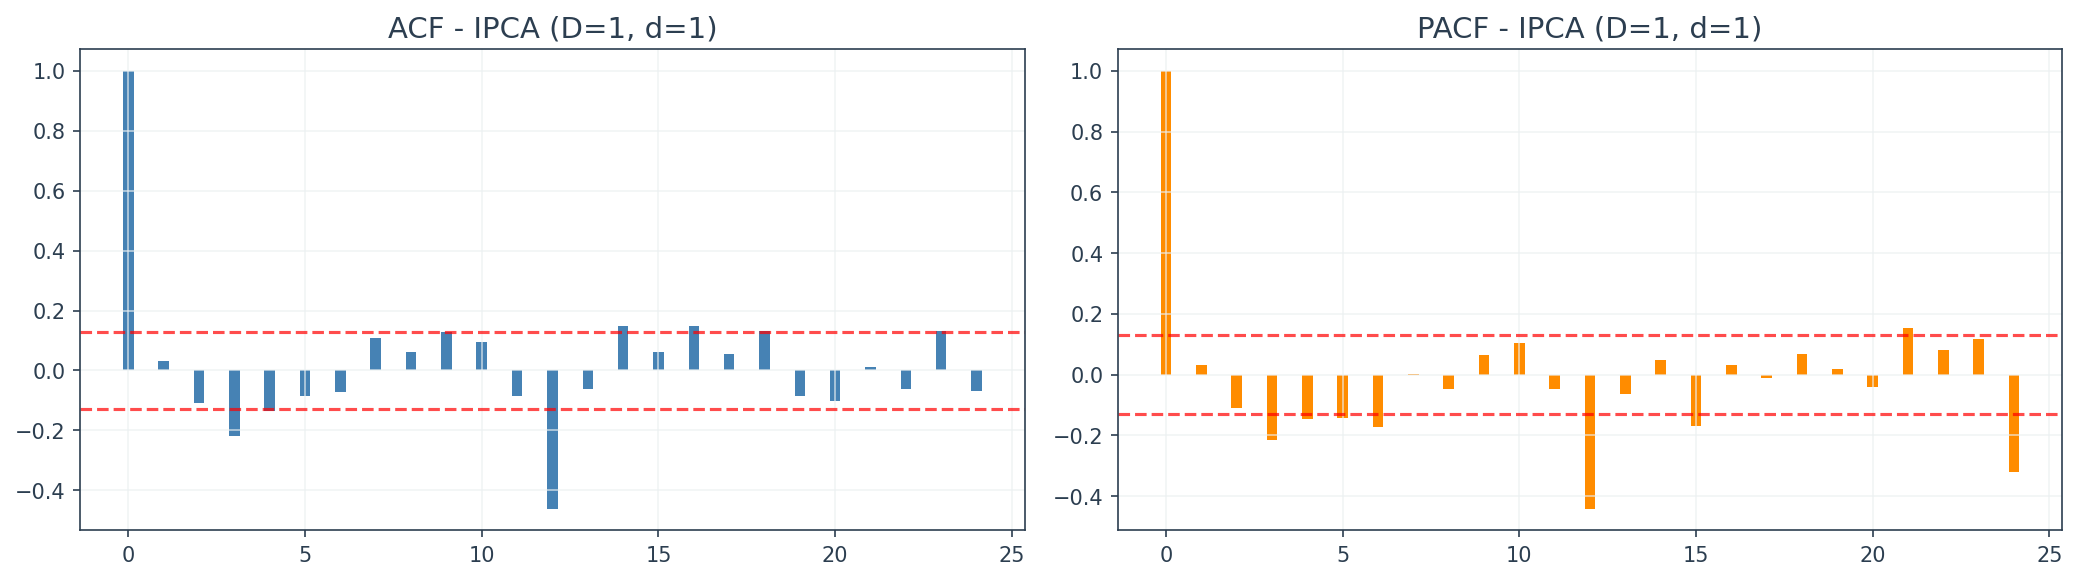

Modelo manual: ARIMA(1,1,1)(0,1,1)[12]
                    Model: ARIMA(1,1,1)(0,1,1)[12]                    
  Nobs: 240    Effective Nobs: 227
  Log-Likelihood: 95.9603
  AIC: -183.9207    BIC: -170.2209    AICc: -183.7405    HQIC: -178.3926
----------------------------------------------------------------------
  Parameter         Estimate    Std.Err    t-value    p-value
----------------------------------------------------------------------
  ar.L1              -0.1462     0.6196    -0.2360     0.8136
  ma.L1               0.1745     0.6138     0.2843     0.7765
  ma.S.L12           -0.9226     0.0748   -12.3258     0.0000
  sigma2              0.0228     0.0023     9.7298     0.0000
  Residual std: 0.1749    Mean: -0.0030
  Ljung-Box(lag=10): stat=24.0264  p-value=0.0075


In [15]:
# Selecao manual baseada em ACF/PACF
y_ipca_sdiff = y_ipca[12:] - y_ipca[:-12]
y_ipca_ddiff = np.diff(y_ipca_sdiff)

max_lag = 24
acf_vals = _compute_acf(y_ipca_ddiff, max_lag)
pacf_vals = _compute_pacf(y_ipca_ddiff, max_lag)
ci = 1.96 / np.sqrt(len(y_ipca_ddiff))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(max_lag + 1), acf_vals, width=0.3, color='steelblue')
axes[0].axhline(ci, color='red', linestyle='--', alpha=0.7)
axes[0].axhline(-ci, color='red', linestyle='--', alpha=0.7)
axes[0].set_title('ACF - IPCA (D=1, d=1)')
axes[1].bar(range(max_lag + 1), pacf_vals, width=0.3, color='darkorange')
axes[1].axhline(ci, color='red', linestyle='--', alpha=0.7)
axes[1].axhline(-ci, color='red', linestyle='--', alpha=0.7)
axes[1].set_title('PACF - IPCA (D=1, d=1)')
plt.tight_layout()
plt.show()

# Modelo manual baseado na analise ACF/PACF
manual_model = ARIMA(order=(1, 1, 1), seasonal_order=(0, 1, 1, 12))
res_manual = manual_model.fit(y_ipca)
print(f'Modelo manual: {manual_model.model_name}')
print(res_manual.summary())

In [16]:
# Comparacao por criterios de informacao
print('=== Criterios de Informacao ===')
print(f'{"Metodo":<25} {"AIC":>10} {"BIC":>10} {"AICc":>10}')
print('-' * 57)
print(f'{"Auto-ARIMA":<25} {best_auto.aic:>10.2f} {best_auto.bic:>10.2f} {best_auto.aicc:>10.2f}')
print(f'{"Manual (ACF/PACF)":<25} {res_manual.aic:>10.2f} {res_manual.bic:>10.2f} {res_manual.aicc:>10.2f}')

# Validacao cruzada temporal
print('\n=== Validacao Cruzada Temporal (5 folds, h=12) ===')

# Use the best auto model's order
auto_order = best_auto.model.order if hasattr(best_auto, 'model') else (1, 1, 1)
auto_seasonal = best_auto.model.seasonal_order if hasattr(best_auto, 'model') else (0, 1, 1, 12)

# CV for auto
cv_auto = rolling_cv(y_ipca, order=auto_order, seasonal_order=auto_seasonal, 
                     n_folds=5, horizon=12, min_train=120)
# CV for manual
cv_manual = rolling_cv(y_ipca, order=(1, 1, 1), seasonal_order=(0, 1, 1, 12),
                       n_folds=5, horizon=12, min_train=120)

print(f'{"Metodo":<25} {"RMSE medio":>12} {"MAE medio":>12}')
print('-' * 50)
print(f'{"Auto-ARIMA":<25} {cv_auto["rmse"].mean():>12.4f} {cv_auto["mae"].mean():>12.4f}')
print(f'{"Manual":<25} {cv_manual["rmse"].mean():>12.4f} {cv_manual["mae"].mean():>12.4f}')

melhor_pred = 'Auto-ARIMA' if cv_auto['rmse'].mean() < cv_manual['rmse'].mean() else 'Manual'
print(f'\nMelhor resultado preditivo: {melhor_pred}')

=== Criterios de Informacao ===
Metodo                           AIC        BIC       AICc
---------------------------------------------------------
Auto-ARIMA                   -263.33    -238.97    -262.85
Manual (ACF/PACF)            -183.92    -170.22    -183.74

=== Validacao Cruzada Temporal (5 folds, h=12) ===


/home/guhaase/projetos/chronobox/chronobox/models/arima.py:644: RuntimeWarning: invalid value encountered in scalar subtract
  neg_ll(p_pp) - neg_ll(p_pm) - neg_ll(p_mp) + neg_ll(p_mm)


Metodo                      RMSE medio    MAE medio
--------------------------------------------------
Auto-ARIMA                      0.1802       0.1444
Manual                          0.4576       0.4088

Melhor resultado preditivo: Auto-ARIMA


## Exercicio 2: Sensibilidade ao Criterio de Informacao - SOLUCAO

In [17]:
# Exercicio 2 - SOLUCAO COMPLETA
print('=== Auto-ARIMA no Nile com diferentes criterios ===')
print()

# AIC
best_aic = auto_arima(y_nile, seasonal=False, max_p=5, max_q=5,
                      information_criterion='aic', stepwise=True, trace=True)
print(f'\nModelo selecionado por AIC: {best_aic.model_name}, AIC={best_aic.aic:.2f}')

print()

# BIC
best_bic = auto_arima(y_nile, seasonal=False, max_p=5, max_q=5,
                      information_criterion='bic', stepwise=True, trace=True)
print(f'\nModelo selecionado por BIC: {best_bic.model_name}, BIC={best_bic.bic:.2f}')

=== Auto-ARIMA no Nile com diferentes criterios ===

  Determined d = 0
Stepwise model selection:
  ARIMA(0,0,0)                        : AIC=1313.0315
  ARIMA(2,0,2)                        : AIC=1284.4829


/home/guhaase/.local/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


  ARIMA(1,0,0)                        : AIC=1285.9059
  ARIMA(0,0,1)                        : AIC=1295.4417


  ARIMA(1,0,2)                        : AIC=1283.3079
  ARIMA(3,0,2)                        : AIC=1286.3632
  ARIMA(2,0,1)                        : AIC=1282.8245


  ARIMA(2,0,3)                        : AIC=1287.3444
  ARIMA(1,0,1)                        : AIC=1282.1265
  ARIMA(1,0,3)                        : AIC=1284.8130


...

  ARIMA(0,0,2)                        : AIC=1291.4746
  ARIMA(2,0,0)                        : AIC=1283.9935

  Best model: ARIMA(1,0,1)  AIC=1282.1265

Modelo selecionado por AIC: ARIMA(1,0,1), AIC=1282.13

  Determined d = 0
Stepwise model selection:
  ARIMA(0,0,0)                        : BIC=1318.2418


/home/guhaase/.local/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


  ARIMA(2,0,2)                        : BIC=1300.1140
  ARIMA(1,0,0)                        : BIC=1293.7214
  ARIMA(0,0,1)                        : BIC=1303.2572
  ARIMA(2,0,0)                        : BIC=1294.4142


  ARIMA(1,0,1)                        : BIC=1292.5471
  ARIMA(2,0,1)                        : BIC=1295.8503
  ARIMA(1,0,2)                        : BIC=1296.3337


  ARIMA(0,0,2)                        : BIC=1301.8952

  Best model: ARIMA(1,0,1)  BIC=1292.5471

Modelo selecionado por BIC: ARIMA(1,0,1), BIC=1292.55


In [18]:
# Comparacao detalhada
print('=== Comparacao AIC vs BIC ===')
print(f'{"Criterio":<15} {"Modelo":<20} {"AIC":>10} {"BIC":>10} {"AICc":>10} {"Params":>8}')
print('-' * 65)
print(f'{"AIC":<15} {best_aic.model_name:<20} {best_aic.aic:>10.2f} {best_aic.bic:>10.2f} {best_aic.aicc:>10.2f} {len(best_aic.params):>8}')
print(f'{"BIC":<15} {best_bic.model_name:<20} {best_bic.aic:>10.2f} {best_bic.bic:>10.2f} {best_bic.aicc:>10.2f} {len(best_bic.params):>8}')

modelos_iguais = best_aic.model_name == best_bic.model_name
print(f'\nModelos iguais? {"Sim" if modelos_iguais else "Nao"}')

if not modelos_iguais:
    print('O BIC penaliza mais a complexidade (k*ln(n) vs 2k), tendendo a selecionar modelos mais parsimoniosos.')
    print('Para o Nile (n=100, serie relativamente simples), a diferenca pode ser pequena.')
else:
    print('Para esta serie, ambos criterios concordam - a complexidade ideal e clara.')

print('\nRecomendacao para o Nile:')
print('- Com n=100, AICc (corrigido) e mais apropriado que AIC')
print('- BIC e consistente (seleciona modelo verdadeiro para n grande)')
print('- Neste caso, ambos concordam em um modelo parsimonioso, tipico de series com estrutura simples.')

=== Comparacao AIC vs BIC ===
Criterio        Modelo                      AIC        BIC       AICc   Params
-----------------------------------------------------------------
AIC             ARIMA(1,0,1)            1282.13    1292.55    1282.55        4
BIC             ARIMA(1,0,1)            1282.13    1292.55    1282.55        4

Modelos iguais? Sim
Para esta serie, ambos criterios concordam - a complexidade ideal e clara.

Recomendacao para o Nile:
- Com n=100, AICc (corrigido) e mais apropriado que AIC
- BIC e consistente (seleciona modelo verdadeiro para n grande)
- Neste caso, ambos concordam em um modelo parsimonioso, tipico de series com estrutura simples.


In [19]:
# Resumo final: melhor modelo por criterio
print('=' * 60)
print('RESUMO: Melhor modelo por criterio de informacao')
print('=' * 60)
for crit, col in [('AIC', 'AIC'), ('BIC', 'BIC'), ('AICc', 'AICc')]:
    best_idx = df_comp_display[col].idxmin()
    best_row = df_comp_display.loc[best_idx]
    print(f'\n{crit}: {best_row["Modelo"]}  ({crit}={best_row[col]:.2f})')


RESUMO: Melhor modelo por criterio de informacao

AIC: ARIMA(0,1,1)(0,1,1)[12]  (AIC=-483.39)

BIC: ARIMA(0,1,1)(0,1,1)[12]  (BIC=-474.77)

AICc: ARIMA(0,1,1)(0,1,1)[12]  (AICc=-483.20)


## Salvando Resultados

In [20]:
# Salvar comparacao em outputs/auto_arima_comparison.csv
comparison_data = []

# Modelos do grid manual (airline)
for _, row in df_comp_display.iterrows():
    comparison_data.append({
        'dataset': 'airline',
        'method': 'manual_grid',
        'model': row['Modelo'],
        'aic': round(float(row['AIC']), 4),
        'bic': round(float(row['BIC']), 4),
        'aicc': round(float(row['AICc']), 4),
        'loglik': round(float(row['LogLik']), 4),
        'n_params': int(row['Params'])
    })

# Auto-ARIMA results
for label, res in [('nile_auto_aicc', best_nile), ('airline_auto_aicc', best_airline)]:
    comparison_data.append({
        'dataset': label.split('_')[0],
        'method': 'auto_arima',
        'model': res.model_name,
        'aic': round(float(res.aic), 4),
        'bic': round(float(res.bic), 4),
        'aicc': round(float(res.aicc), 4),
        'loglik': round(float(res.loglike), 4),
        'n_params': len(res.params)
    })

# IPCA auto vs manual
for label, res in [('ipca_auto', best_auto), ('ipca_manual', res_manual)]:
    comparison_data.append({
        'dataset': 'ipca',
        'method': label.split('_')[1],
        'model': res.model_name,
        'aic': round(float(res.aic), 4),
        'bic': round(float(res.bic), 4),
        'aicc': round(float(res.aicc), 4),
        'loglik': round(float(res.loglike), 4),
        'n_params': len(res.params)
    })

# Nile AIC vs BIC
for label, res in [('nile_aic_selection', best_aic), ('nile_bic_selection', best_bic)]:
    comparison_data.append({
        'dataset': 'nile',
        'method': label.replace('nile_', ''),
        'model': res.model_name,
        'aic': round(float(res.aic), 4),
        'bic': round(float(res.bic), 4),
        'aicc': round(float(res.aicc), 4),
        'loglik': round(float(res.loglike), 4),
        'n_params': len(res.params)
    })

df_output = pd.DataFrame(comparison_data)
output_path = os.path.join(OUTPUT_DIR, 'auto_arima_comparison.csv')
df_output.to_csv(output_path, index=False)

print(f'Comparacao salva em: {output_path}')
print(f'Total de linhas: {len(df_output)}')
print(df_output.to_string(index=False))

Comparacao salva em: /home/guhaase/projetos/chronobox/examples/arima/outputs/auto_arima_comparison.csv
Total de linhas: 13
dataset        method                   model       aic       bic      aicc    loglik  n_params
airline   manual_grid ARIMA(0,1,1)(0,1,1)[12] -483.3930 -474.7674 -483.2040  244.6965         3
airline   manual_grid ARIMA(0,1,1)(1,1,1)[12] -481.9063 -470.4055 -481.5888  244.9531         4
airline   manual_grid ARIMA(1,1,1)(0,1,1)[12] -481.8930 -470.3922 -481.5755  244.9465         4
airline   manual_grid ARIMA(1,1,0)(0,1,1)[12] -481.4838 -472.8582 -481.2949  243.7419         3
airline   manual_grid ARIMA(0,1,2)(0,1,1)[12] -481.6103 -470.1095 -481.2929  244.8052         4
airline   manual_grid ARIMA(1,1,1)(1,1,1)[12] -480.3038 -465.9278 -479.8238  245.1519         5
airline   manual_grid ARIMA(2,1,1)(0,1,1)[12] -479.8125 -465.4366 -479.3325  244.9063         5
   nile    auto_arima            ARIMA(1,0,1) 1282.1265 1292.5471 1282.5475 -637.0632         4
airline    au

## Conclusao

Neste notebook, exploramos a selecao automatica de ordem para modelos ARIMA/SARIMA:

1. **Criterios de Informacao**: AIC, BIC e AICc oferecem diferentes trade-offs entre ajuste e parcimonia. O AICc e preferivel para amostras pequenas, enquanto o BIC tende a selecionar modelos mais simples.

2. **Auto-ARIMA**: A busca automatica (stepwise ou grid search) simplifica enormemente o processo de selecao de ordem, evitando a analise manual de ACF/PACF.

3. **Stepwise vs Grid Search**: O metodo stepwise e significativamente mais rapido, geralmente encontrando o mesmo modelo otimo ou um muito proximo.

4. **Validacao Cruzada Temporal**: Criterios de informacao nao substituem a validacao preditiva. A CV temporal (rolling window) fornece estimativas mais realistas do desempenho de previsao.

5. **Auto vs Manual**: A selecao automatica frequentemente concorda com a analise manual baseada em ACF/PACF, mas e mais sistematica e reprodutivel.

### Recomendacoes praticas:
- Use `auto_arima` com `stepwise=True` como ponto de partida
- Valide com CV temporal, nao apenas criterios de informacao
- Prefira AICc para amostras com $n/k < 40$
- Sempre verifique os diagnosticos dos residuos do modelo selecionado